# Weak SINDy for PDEs

In early works on PDE discovery with SINDy such as [(Rudy, 2017)](https://www.science.org/doi/full/10.1126/sciadv.1602614), it was shown that simple amendments to the library function $\Theta(X)$ can be augmented to include partial derivatives. Thereby, allowing PDE equations to be discovered. Such methods are termed PDE-FIND and implemented within PySINDy as the `PDELibrary`. However, this method is prone to ill-conditioned optimization problems and not well suited for discovering many PDE problems (as we will soon see in the benchmarks at the end of this tutorial).

The weak form can also be adapted for PDE discovery. For this tutorial, we base our weak form for PDE on [(Messenger and Bortz, 2021)](https://www.sciencedirect.com/science/article/pii/S0021999121004204) with published [MATLAB code](https://github.com/MathBioCU/WSINDy_PDE). Our Python implementation of this method is found in `WSINDy_PDE`. In this tutorial, we will:
1. Explain the generalization of the weak form and how its test function can be adapted for derivatives in any spatial dimension.
2. Demonstrate how convolution with the test function can be done via fast Fourier transforms (FFTs).
3. Formulate the sparse regression problem that SINDy can solve.

In [3]:
# Import all required libraries

import numpy as np
import pysindy as ps
import matplotlib.pyplot as plt
import warnings
from typing import Callable
from IPython.display import display, Math

from sindy.weak.wsindy_pde import WSINDy_PDE, benchmark_wsindy_pde
from sindy.utils import set_seed, add_gauss_noise
from sindy.pdes import \
    inviscid_burgers, \
    kuramato_sivashinsky, \
    korteweg_de_vries, \
    shallow_water, \
    reaction_diffusion_2d
from sindy.ivp_solvers import rk4
from sindy.plot_utils import \
    init_plt_format, \
    visualize_pde_1d, \
    visualize_pde_2d

# Suppress sparsity warnings when carrying out hyperparameter sweep
warnings.filterwarnings('ignore', category=UserWarning, module='pysindy')
warnings.filterwarnings('ignore', category=RuntimeWarning)

init_plt_format()
set_seed(0)

# WSINDy for PDEs Methodology

Building on the Galerkin based approach in WSINDy for ODEs, let us assume that a spatiotemporal PDE equation has the form

$$
D^{\alpha^0} u(x, t)
    = D^{\alpha^1} g_1(u(x, t))
    + D^{\alpha^2} g_2(u(x, t))
    + \dots
    + D^{\alpha^S} g_S(u(x, t)),
\qquad x \in \Omega, \ t \in (0, T)
$$

where

$$
D^{\alpha^s} u(x, t)
    = \frac
        {\partial^{
            \alpha_1^s
            + \dots
            + \alpha_D^s
            + \alpha_{D+1}^s
        }}
        {
            \partial x_1^{\alpha_1^s}
            \dots
            \partial x_D^{\alpha_D^s}
            \partial t^{\alpha_{D+1}^s}
        } u(x, t)
$$

and $D^{\alpha^0}$ represents the temporal derivative. The dataset $\mathbf{U}(\mathbf{X}, t)$ is positioned on the discrete grid

$$
(\mathbf{x}_k, t_k)
    = (\mathbf{X}_{k_1, \dots, k_D}, t_{k_{D+1}})
    = (x_{k_1}, \dots, x_{k_D}, t_{k_{D+1}}) \in \mathbb{R}^D \times \mathbb{R}
$$

Let us assume that the function $g$ can be represented by a family of function $f_j(u)$ such that

$$D^{\alpha^0} u = \sum_{s=1}^S \sum_{j=1}^J \mathbf{w}^\star_{(s-1)J+j} D^{\alpha^s} f_j(u) $$

If we apply the weak form by multiplying both sides by a smooth test function $\psi(x,t)$ that is compactly supported over the domain $\omega$, then integrating it over the spacetime domain, we obtain

$$
\left< \psi, D^{\alpha^0} u \right>
    = \sum_{s=1}^S \sum_{j=1}^J \mathbf{w}^\star_{(s-1)J+j} \left< \psi, D^{\alpha^s} f_j(u) \right>
$$

where

$$\left< \psi, f \right> := \int_0^T \int_\Omega \psi(x, t) f(x, t) \, dx dt$$

Subsequently, we can apply integration by parts to arrive at

$$
\left< (-1)^{|\alpha^0|} D^{\alpha^0} \psi, u \right>
    = \sum_{s=1}^S \sum_{j=1}^J \mathbf{w}^\star_{(s-1)J+j} \left<
        (-1)^{|\alpha^s|} D^{\alpha^s} \psi,
        f_j(u)
    \right>
$$\

This would result in a linear equation

$$\mathbf{b} = \mathbf{G}\mathbf{w}$$

where

$$
\begin{cases}
    \mathbf{b}_k = \left\langle (-1)^{|\alpha^0|} D^{\alpha^0} \psi_k, \mathbf{U} \right\rangle, \\
    \mathbf{G}_{k, (s-1)J+j} = \left\langle (-1)^{|\alpha^s|} D^{\alpha^s} \psi_k, f_j(\mathbf{U}) \right\rangle,
\end{cases}
$$

which can be solved via sparse regression such as STLSQ.


## The Test Function

Let us define the same basis piecewise unimodal polynomial test function where

$$
\phi(v) =
\begin{cases}
(v-a)^p(b-v)^p & v \in [-1, 1], \\
0 & \text{otherwise}
\end{cases}
$$

Note that the test function is compactly supported within the domain $v \in [-1,1]$ on $2m+1$ number of discrete points. The hyperparameters $m$ number of support points and $p$ degree test function polynomial are determined through analysis of the residual spectral decay. We refer the reader to [(Messenger and Bortz, 2021)](https://www.sciencedirect.com/science/article/pii/S0021999121004204) for detailed justification and derivation. The implementation of hyperparameter selection of $m$ and $p$ are found in `WSINDy_PDE._get_support_pts` and `WSINDy_PDE._get_test_func_basis` respectively.

Depending on the spatial dimension of a given PDE, it would require the generation of a corresponding number of basis test functions where the final test function $\psi(x, t)$ is defined by

$$\psi(x, t) = \phi_1(x_1) \cdots \phi_D(x_D)\phi_{D+1}(t)$$

which enables the separation of variables. The tensor product of the test function for a 1D PDE is visualized below.

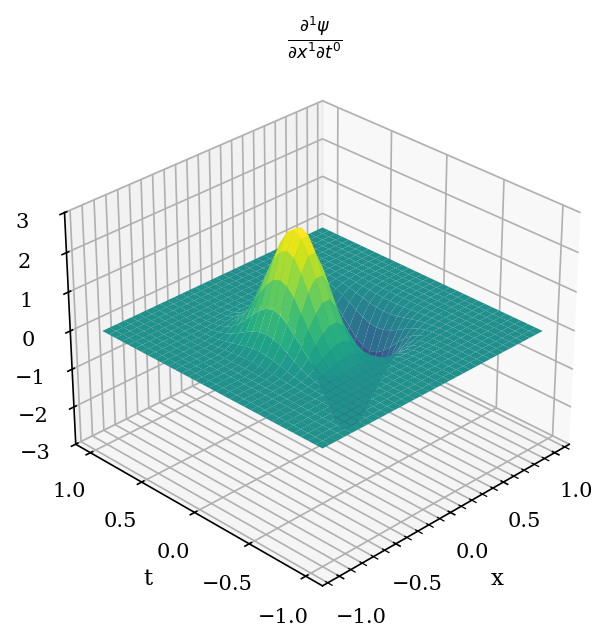

In [4]:
# Alpha vector that defines the partial derivative operator
alpha: list = [1,0]

# Define number of support points
m: int = 16

# Define spatiotemporal grid
x: np.ndarray = np.linspace(-1, 1, 2*m+1)
t: np.ndarray = np.linspace(-1, 1, 2*m+1)

# Obtain basis test functions phi
wsindy = WSINDy_PDE()
phi_x = wsindy._get_test_func_basis(m, alpha[0])[0]
phi_t = wsindy._get_test_func_basis(m, alpha[1])[0]

# Tensor product via broadcasting
[T,X] = np.meshgrid(t,x)
psi = phi_x[alpha[0],:].reshape((-1,1)) * phi_t[alpha[1],:].reshape((1,-1))

# Plot test function
_, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(X, T, psi, cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title(
    fr'$\frac{{\partial^{{{sum(alpha)}}} \psi}}' \
        + fr'{{\partial x^{{{alpha[0]}}}' \
        + fr'\partial t^{{{alpha[1]}}}}}$'
)
ax.view_init(azim=225);

Once the test function has been constructed on the grid domain $v \in [-1,1]$, its derivatives must be scaled accordingly as it must be scaled back to its original $x$ domain defined by $x = ym\Delta x$ where

$$
\frac{\partial^n \phi}{\partial x^n}
    = \frac{\partial^n \phi}{\partial v^n} \left( \frac{dv}{dx} \right)^n
    = \frac{\partial^n \phi}{\partial v^n} \left( m\Delta x \right)^{-n}
$$

## Convolutional Weak Form and Solving via Fourier Space

We now adopt the uniform grid approach from the WSINDy for ODEs by defining each case of test function $\psi_k$ be a translation of the reference test function such that

$$\psi_k(x,t) = \psi(x_k - x, t_k - t)$$

We convolve the test function with the solution variable $\mathbf{U}$ such that

$$
\left( D^{\alpha^0} \psi \right) * u(\mathbf{x}_k, t_k)
    = \sum_{s=1}^S \sum_{j=1}^J
    \mathbf{w}^\star_{(s-1)J+j}
    \left( D^{\alpha^s} \psi \right)
    * f_j(u)(\mathbf{x}_k, t_k)
$$

Such a convolution can be solved efficiently in the Fourier space via the fast Fourier transform (FFT) algorithm, as convolution in the time domain is equivalent to multiplication in frequency domain. It should be noted that such convolution may also be solved efficiently using banded matrix operations but it would not benefit from spectral decay of high frequency noise as reasoned in the paper.

Below is an example convolution using FFT operations on a 1D arbitrarily defined PDE solution.

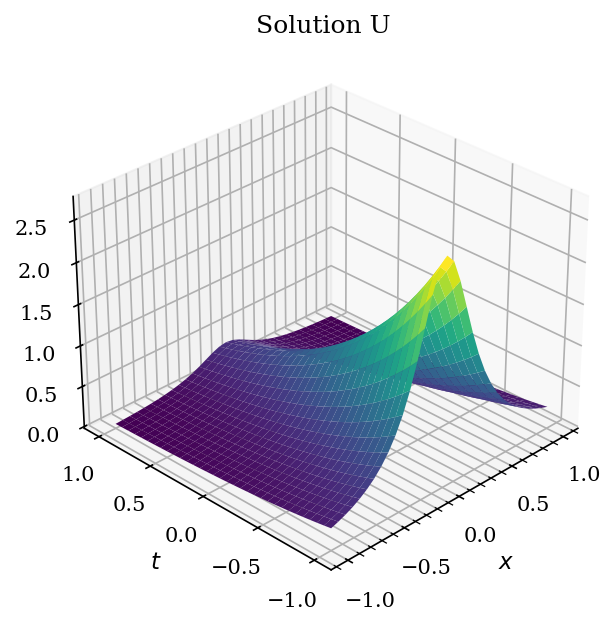

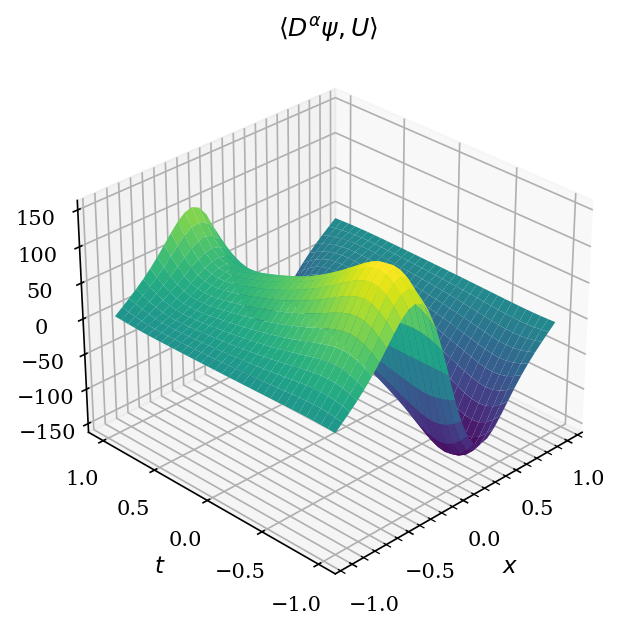

In [5]:
# Define an arbitrary 1D spatiotemporal solution
U = np.exp(-T) / (1+10*X**2)

# Visualize our arbitrary solution
_, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(X, T, U, cmap='viridis')
ax.set_xlabel('$x$')
ax.set_ylabel('$t$')
ax.set_zlabel('$u$')
ax.view_init(azim=225)
ax.set_title('Solution U')

# Fourier transform the test function
psi_rolled = np.roll(phi_x[alpha[0],:], -m).reshape((-1,1)) \
    * np.roll(phi_t[alpha[1],:], -m).reshape((1,-1))

# Convolve it with our test function defined earlier using FFT-based method
U_hat = np.fft.fftn(U)
psi_hat = np.fft.fftn(psi_rolled)
Upsi_hat = U_hat * psi_hat
Upsi = np.fft.ifftn(Upsi_hat).real

# Visualize the convolved solution
_, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(X, T, Upsi, cmap='viridis')
ax.set_xlabel('$x$')
ax.set_ylabel('$t$')
ax.view_init(azim=225)
ax.set_title(fr'$\left< D^{{\alpha}} \psi, U \right>$');

## Subsampling Points

Note that by convolving all solution grid points with the test function, we yield $$K = \prod_{d=0}^{D} (N_d - 2m)$$ number of test functions and $K$ query points. In order reduce the total number of test functions. Let us subsample only at regular intervals determined by the parameter $s_d$ which subsamples at interval $s_d \Delta x$ such that we have a total of 

$$K = \prod_{d=1}^{D+1} \left\lfloor \frac{N_d - 2m_d}{s_d} \right\rfloor$$

query points. The implementation is found in `WSINDy._get_subsample_mask`.


## Sparse Regression

Now that we have

$$
\begin{cases}
    \mathbf{b}_k = \left\langle D^{\alpha^0} \psi_k, \mathbf{U} \right\rangle, \\
    \mathbf{G}_{k, (s-1)J+j} = \left\langle D^{\alpha^s} \psi_k, f_j(\mathbf{U}) \right\rangle,
\end{cases}
$$

we may now begin to build our linear regression problem as implemented in

In [6]:
WSINDy_PDE._build_linear_eqn??

Signature:
WSINDy_PDE._build_linear_eqn(
    self,
    u_sol: numpy.ndarray,
    phi_x_hats: list[numpy.ndarray],
    phi_t_hat: numpy.ndarray,
    subsample_mask: numpy.ndarray,
) -> tuple[numpy.ndarray, numpy.ndarray, list[str]]
Source:   
    def _build_linear_eqn(
            self,
            u_sol: np.ndarray,
            phi_x_hats: list[np.ndarray], phi_t_hat: np.ndarray,
            subsample_mask: np.ndarray
    ) -> tuple[np.ndarray, np.ndarray, list[str]]:
        """
        Function that builds LHS and RHS matrices by convolving the appropriate
        test functions with the solution variables and candidate function
        library respectively.

        Args:
            u_sol (np.ndarray): The solution array.
            phi_x_hats (list[np.ndarray]): The spatial test functions.
            phi_t_hat (np.ndarray): The temporal test function.
            subsample_mask (Optional[np.ndarray], optional): Subsample mask to
                be used for querying.

        Ret

# Data Generation

For demonstration purposes, let us generate the following datasets. More information on the equations can be found in the [data generation tutorial](../../S0%20Miscellaneous/Data%20Generation.ipynb).

## 1D PDEs

Let us first define the noise ratios that we will use in this tutorial.

In [7]:
# Define noise ratios to test
noise_ratios: np.ndarray = np.logspace(-6, 0)

# Define noise ratio index to visualize
noise_idx: int = int(len(noise_ratios) * 0.75)

### Inviscid Burgers PDE

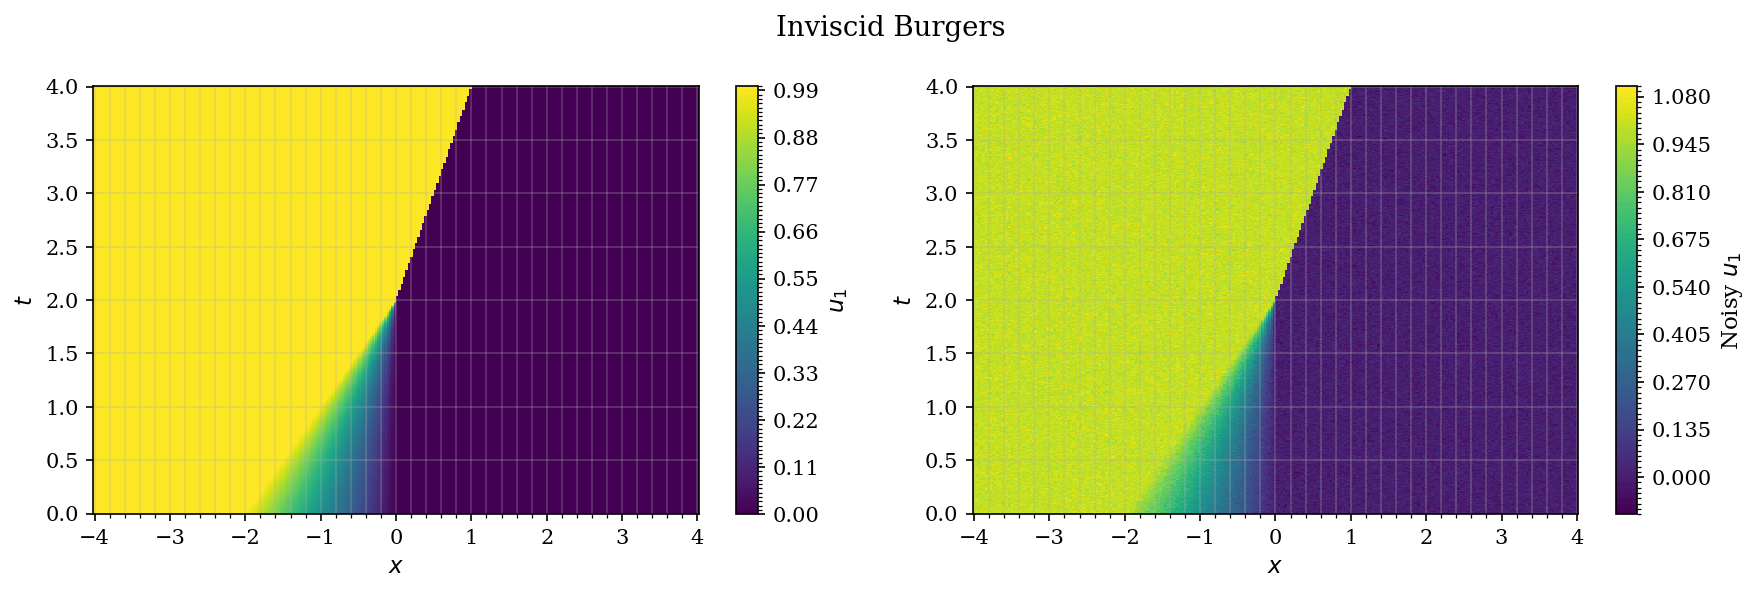

In [8]:
burgers_u, burgers_t, burgers_x = inviscid_burgers(
    tFinal=4, dt=0.01,
    total_x_pts=256, xbounds=(-4, 4),
    A = 1
)
burgers_noisy_us: list[np.ndarray] = [
    add_gauss_noise(burgers_u, nr) for nr in noise_ratios
]

visualize_pde_1d(
    burgers_u, burgers_t, burgers_x,
    'Inviscid Burgers',
    burgers_noisy_us[noise_idx]
)

### Kuramato-Sivashinsky PDE

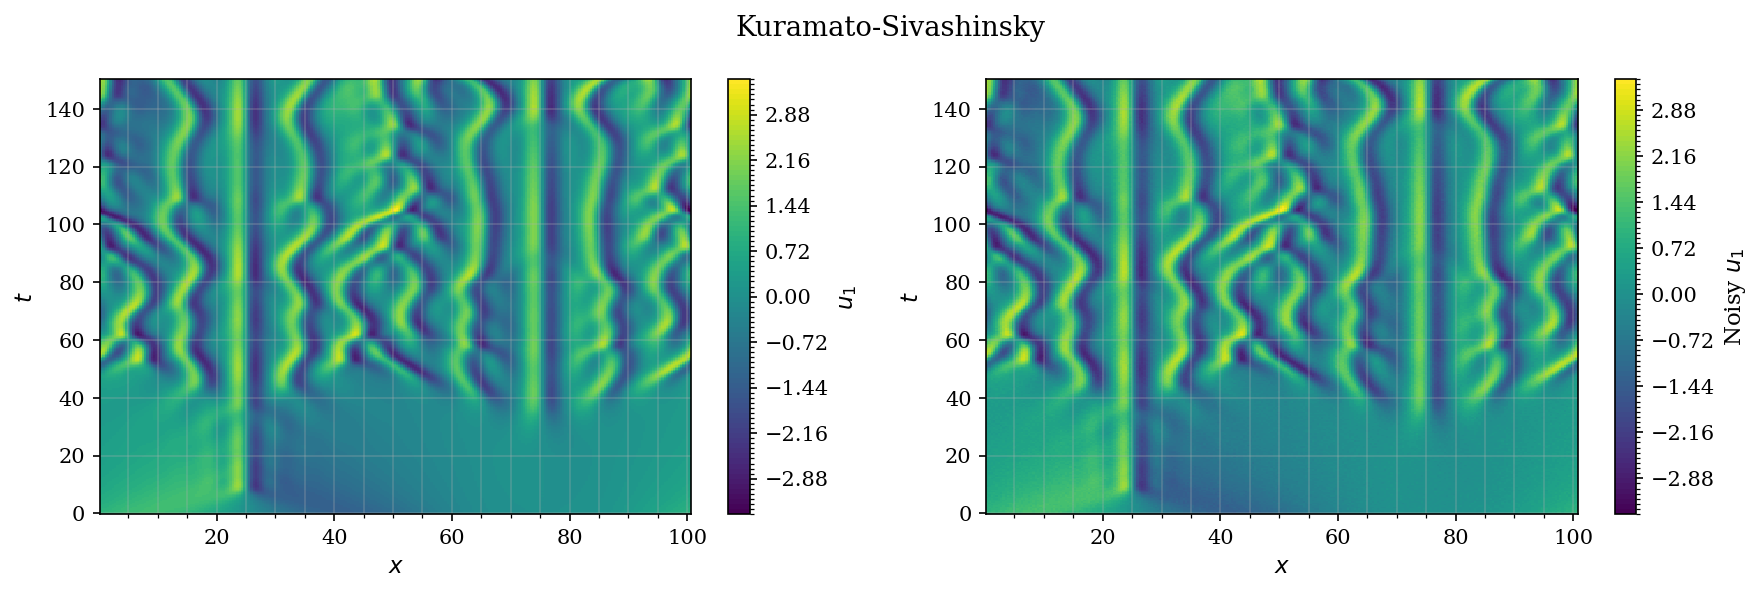

In [9]:
# ------------------------ Kuramato-Sivashinsky PDE ------------------------ #

ks_u0: Callable = lambda x: np.cos(x/16) * (1 + np.sin(x/16))
ks_u, ks_t, ks_x = kuramato_sivashinsky(
    tFinal=150, dt=0.5,
    total_x_pts=256, xbounds=(0, 32*np.pi),
    u0_func=ks_u0
)
ks_noisy_us: list[np.ndarray] = [
    add_gauss_noise(ks_u, nr) for nr in noise_ratios
]

visualize_pde_1d(
    ks_u, ks_t, ks_x,
    'Kuramato-Sivashinsky',
    ks_noisy_us[noise_idx]
)

### Korteweg de Vries PDE

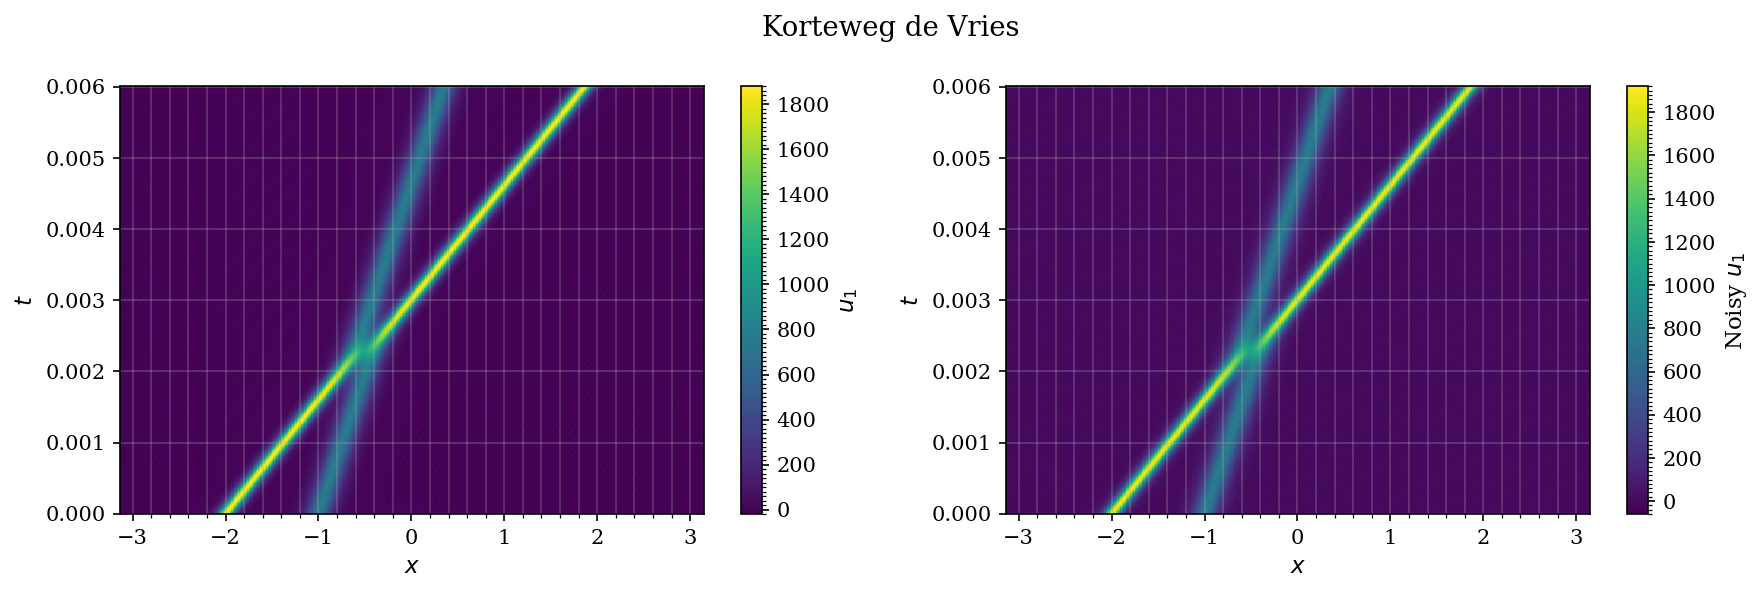

In [10]:
# ------------------------ Korteweg de Vries PDE ------------------------ #

kdv_u0_A: float = 25
kdv_u0_B: float = 16
kdv_u0: Callable = lambda x: 3*kdv_u0_A**2 / np.cosh(0.5*kdv_u0_A*(x+2))**2 \
    + 3*kdv_u0_B**2 / np.cosh(0.5*kdv_u0_B*(x+1))**2
kdv_u, kdv_t, kdv_x = korteweg_de_vries(
    tFinal=6e-3, dt=1e-5,
    total_x_pts=400, xbounds=(-np.pi, np.pi),
    u0_func=kdv_u0
)
kdv_noisy_us: list[np.ndarray] = [
    add_gauss_noise(kdv_u, nr) for nr in noise_ratios
]

visualize_pde_1d(
    kdv_u, kdv_t, kdv_x,
    'Korteweg de Vries',
    kdv_noisy_us[noise_idx]
)

## 2D PDEs

### Reaction-Diffusion Equation

In [11]:
# ------------------------ 2D Reaction-Diffusion ------------------------ #

rd2d_x_grids: list[np.ndarray] = [
    np.linspace(-10, 10, 100),
    np.linspace(-10, 10, 100)
]
rd2d_mesh: np.ndarray = np.meshgrid(*rd2d_x_grids)
rd2d_polar_r: np.ndarray = np.sqrt(rd2d_mesh[0]**2 + rd2d_mesh[1]**2)
rd2d_polar_theta: np.ndarray = np.angle(rd2d_mesh[0] + 1j*rd2d_mesh[1])
rd2d_u0: np.ndarray = np.stack((
    np.tanh(rd2d_polar_r) \
        * np.cos(rd2d_polar_theta - np.pi*rd2d_polar_r),
    np.tanh(rd2d_polar_r) \
        * np.sin(rd2d_polar_theta - np.pi*rd2d_polar_r),
), axis=-1)
rd2d_t, rd2d_u = rk4(
    reaction_diffusion_2d,
    tFinal = 5, dt = 1e-2,
    y0 = rd2d_u0,
    args = (rd2d_x_grids,)
)
rd2d_noisy_u: list[np.ndarray] = [
    add_gauss_noise(rd2d_u, nr) for nr in noise_ratios
]

visualize_pde_2d(
    rd2d_u, rd2d_t, rd2d_x_grids,
    '2D Reaction-Diffusion',
    variable_names=['u', 'v'],
    noisy_u=rd2d_noisy_u[noise_idx],
    equal_axis=True,
    frame_interval=50
)

### Shallow Water Equation

In [12]:
# ------------------------ Shallow Water Equation ------------------------ #

sw_x_grids: list[np.ndarray] = [
    np.linspace(0, 99, 100),
    np.linspace(0, 99, 100)
]
sw_u0: np.ndarray = np.stack((
    np.zeros((len(sw_x_grids[0]), len(sw_x_grids[1]))),
    np.zeros((len(sw_x_grids[0]), len(sw_x_grids[1]))),
    np.exp(-(
        (sw_x_grids[0][:, None] - 50)**2
        + (sw_x_grids[1][None, :] - 50)**2
    )/25) + 1
), axis=-1)
sw_t, sw_u = rk4(
    shallow_water,
    tFinal = 20, dt = 0.1,
    y0 = sw_u0,
    args = (sw_x_grids,)
)
sw_noisy_u: list[np.ndarray] = [
    add_gauss_noise(sw_u, nr) for nr in noise_ratios
]

visualize_pde_2d(
    sw_u[..., [2]], sw_t, sw_x_grids,
    'Shallow Water Equation (Height State)',
    noisy_u=sw_noisy_u[noise_idx][..., [2]],
    equal_axis=True,
    frame_interval=10
)

and run it through a sparse regression optimizer.

# Demonstration of WSINDy

Let us attempt to recover the equations using clean data first.

## 1D Burgers equation

In [13]:
wsindy = WSINDy_PDE(poly_order=3, max_dx=4)
wsindy.fit(burgers_u, burgers_x, burgers_t)
display(Math(wsindy.print()))

<IPython.core.display.Math object>

## 1D Kuramoto-Sivashinsky equation

In [14]:
wsindy = WSINDy_PDE(poly_order=3, max_dx=4)
wsindy.fit(ks_u, ks_x, ks_t)
display(Math(wsindy.print()))

<IPython.core.display.Math object>

## 1D Korteweg-de-Vries equation

A note on the Korteweg de Vries equation, due to the relatively large range of magnitude in the solution, this results in an ill-conditioned regression problem. Regularisation via scaling is required for data with large amplitude ranges.

In [15]:
wsindy = WSINDy_PDE(poly_order=3, max_dx=4)
wsindy.fit(kdv_u, kdv_x, kdv_t)
display(Math(wsindy.print()))

<IPython.core.display.Math object>

## 2D Reaction-Diffusion equation

In [16]:
wsindy = WSINDy_PDE(poly_order=3, max_dx=4)
wsindy.fit(rd2d_u, rd2d_x_grids, rd2d_t)
display(Math(wsindy.print()))

<IPython.core.display.Math object>

## 2D Shallow Water equation

A note on the shallow water equation which is defined as

$$
\begin{align}
0 &= \frac{\partial}{\partial t}(hu) + \frac{\partial}{\partial x}(hu^2 + \frac{1}{2}gh^2) + \frac{\partial}{\partial y}(huv) \\
0 &= \frac{\partial}{\partial t}(hv) + \frac{\partial}{\partial y}(hv^2 + \frac{1}{2}gh^2) + \frac{\partial}{\partial x}(huv) \\
0 &= \frac{\partial}{\partial t}(h) + \frac{\partial}{\partial x}(hu) + \frac{\partial}{\partial y}(hv)
\end{align}
$$

When manipulated into the time derivative of individual variables, it is defined as

$$
\begin{align}
\frac{\partial u}{\partial t} &= - u\frac{\partial u}{\partial x} - v\frac{\partial u}{\partial y} - g \frac{\partial h}{\partial x} \\
\frac{\partial v}{\partial t} &= - u\frac{\partial v}{\partial x} - v\frac{\partial v}{\partial y} - g \frac{\partial h}{\partial y} \\
\frac{\partial h}{\partial t} &= - \frac{\partial}{\partial x}(hu) - \frac{\partial}{\partial y}(hv)
\end{align}
$$

Due to the formulation of weak SINDy, such equations cannot be discovered directly. Instead, the data should be manipulated into its flux form defined as 

$$
\begin{align}
0 &= \frac{\partial F_1}{\partial t}
    + \frac{\partial}{\partial x} \left( \frac{F_1^2}{F_3} + \frac{1}{2}gF_3^2 \right)
    + \frac{\partial}{\partial y} \left(\frac{F_1F_2}{F_3} \right) \\
0 &= \frac{\partial F_2}{\partial t}
    + \frac{\partial}{\partial x} \left( \frac{F_2^2}{F_3} + \frac{1}{2}gF_3^2 \right)
    + \frac{\partial}{\partial y} \left(\frac{F_1F_2}{F_3} \right) \\
0 &= \frac{\partial F_3}{\partial t} + \frac{\partial F_1}{\partial x} + \frac{\partial F_2}{\partial y}
\end{align}
$$

where the flux is defined as $F = [hu, hv, h]^T$ which can be discovered with the appropriate candidate function library or using implicit SINDy. With the right settings of the current implementation, a modified form of the shallow water equation can be discovered which replaces cross-advection terms with self-advection terms.

In [17]:
wsindy = WSINDy_PDE(poly_order=2, max_dx=1, lam=0.1)
wsindy.fit(sw_u, sw_x_grids, sw_t)
display(Math(wsindy.print()))

<IPython.core.display.Math object>

# Benchmarking Weak Form SINDy

Using the same metrics employed in the benchmarking of weak form SINDy for ODEs, let us benchmark weak form with PySINDy's `PDELibrary` based on PDE-FIND from [(Rudy et al, 2017)](https://www.science.org/doi/full/10.1126/sciadv.1602614). Note that the threshold parameter has to be increased here in order to recover the correct form of PDE equation with PDE-FIND.

In [18]:
# Define WSINDy library parameters (changing these will require changing the
# true coefficient matrices)
poly_order: int = 3
include_bias: bool = True

# Set WSINDy hyperparameters
lam: float = 0.1
max_dx: int = 4

## 1D Kuramato-Sivashinsky equation

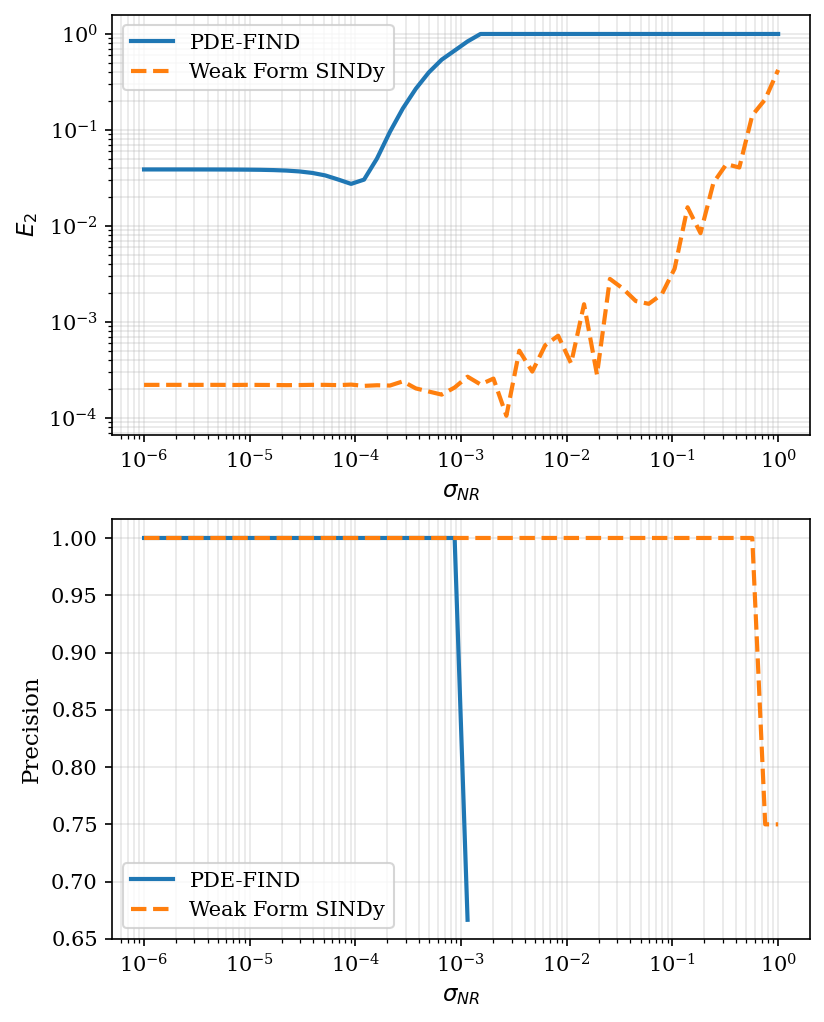

In [19]:
# Define the true coefficient matrix for SINDy
xi_sindy = np.zeros((1, 20))
xi_sindy[0, [5, 7, 8]] = -1.0

# Define the true coefficient matrix for WSINDy
xi_wsindy = np.zeros((16, 1))
xi_wsindy[5, 0] = -0.5
xi_wsindy[[7, 13], 0] = -1.0

# Benchmark the methods
benchmark_wsindy_pde(
    ks_noisy_us, noise_ratios,
    ks_x, ks_t,
    xi_sindy, xi_wsindy,
    wsindy_kwargs={
        'poly_order': poly_order,
        'include_bias': include_bias,
        'lam': lam,
        'max_dx': max_dx
    },
    sindy_lib_kwargs={
        'function_library': ps.PolynomialLibrary(poly_order, include_bias=False),
        'derivative_order': max_dx,
        'include_bias': include_bias,
        'spatial_grid': ks_x,
        'diff_kwargs': {'periodic': True}
    },
    sindy_opti_kwargs={'threshold': lam}
)

## 1D Burgers equation

Recall that in the *inviscid* 1D Burgers equation, a shock forms at $t=2$. Employing finite difference with PDE-FIND fails to yield any reasonable model. Numerical solvers that rely on finite difference methods often yield poor solutions from discontinuities, which may manifest in the form of oscillations or dispersions depending on the specific solver. The same limitations apply to inverse model discovery.

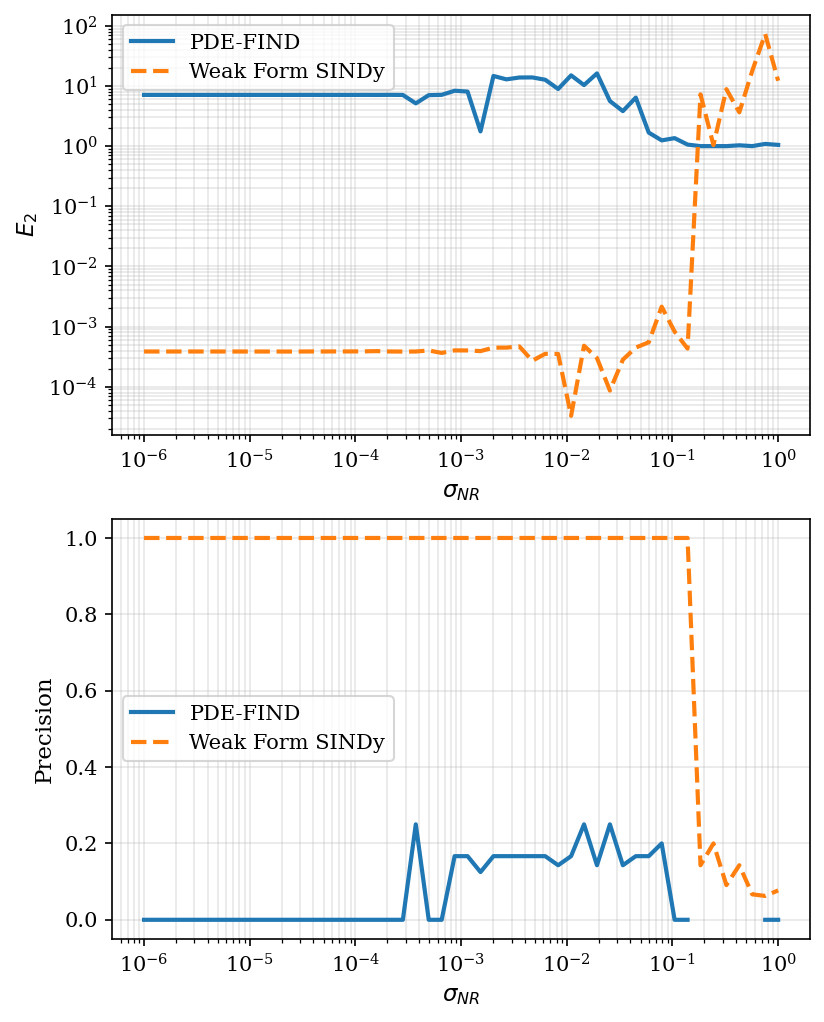

In [20]:
# Define the true coefficient matrix for SINDy
xi_sindy = np.zeros((1, 20))
xi_sindy[0, 8] = -1.0

# Define the true coefficient matrix for WSINDy
xi_wsindy = np.zeros((16, 1))
xi_wsindy[5, 0] = -0.5

# Benchmark the methods
benchmark_wsindy_pde(
    burgers_noisy_us, noise_ratios,
    burgers_x, burgers_t,
    xi_sindy, xi_wsindy,
    wsindy_kwargs={
        'poly_order': poly_order,
        'include_bias': include_bias,
        'lam': lam,
        'max_dx': max_dx
    },
    sindy_lib_kwargs={
        'function_library': ps.PolynomialLibrary(poly_order, include_bias=False),
        'derivative_order': max_dx,
        'include_bias': include_bias,
        'spatial_grid': burgers_x,
        'diff_kwargs': {'periodic': False}
    },
    sindy_opti_kwargs={'threshold': lam}
)

However, if we remove the data points with shocks, we may still recover a reasonable model using PDE-FIND. However, it is significantly more sensitive to noise and the choice of threshold hyerparapmeter $\lambda$.

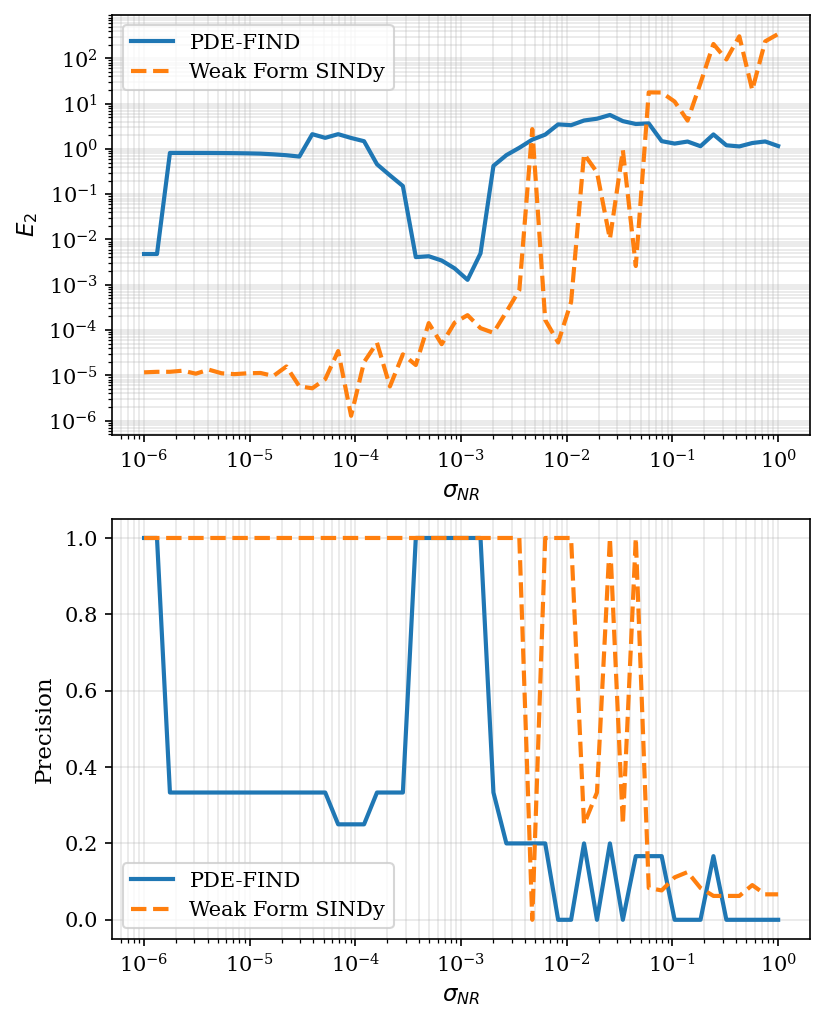

In [21]:
tFinal: float = 1
tIdx: int = np.searchsorted(burgers_t, tFinal)

# Benchmark the methods
benchmark_wsindy_pde(
    [u[:,:100,:] for u in burgers_noisy_us], noise_ratios,
    burgers_x, burgers_t[:100],
    xi_sindy, xi_wsindy,
    wsindy_kwargs={
        'poly_order': poly_order,
        'include_bias': include_bias,
        'lam': lam,
        'max_dx': max_dx
    },
    sindy_lib_kwargs={
        'function_library': ps.PolynomialLibrary(poly_order, include_bias=False),
        'derivative_order': max_dx,
        'include_bias': include_bias,
        'spatial_grid': burgers_x,
        'diff_kwargs': {'periodic': False}
    },
    sindy_opti_kwargs={'threshold': lam}
)

## 1D Korteweg de Vries equation

Due to both a high derivative order in the Korteweg de Vries equation exacerbated by the challenging initial condition that results in a large range of magnitudes in the solution, this particular solution is not amenable to be discovered using PDE-FIND.

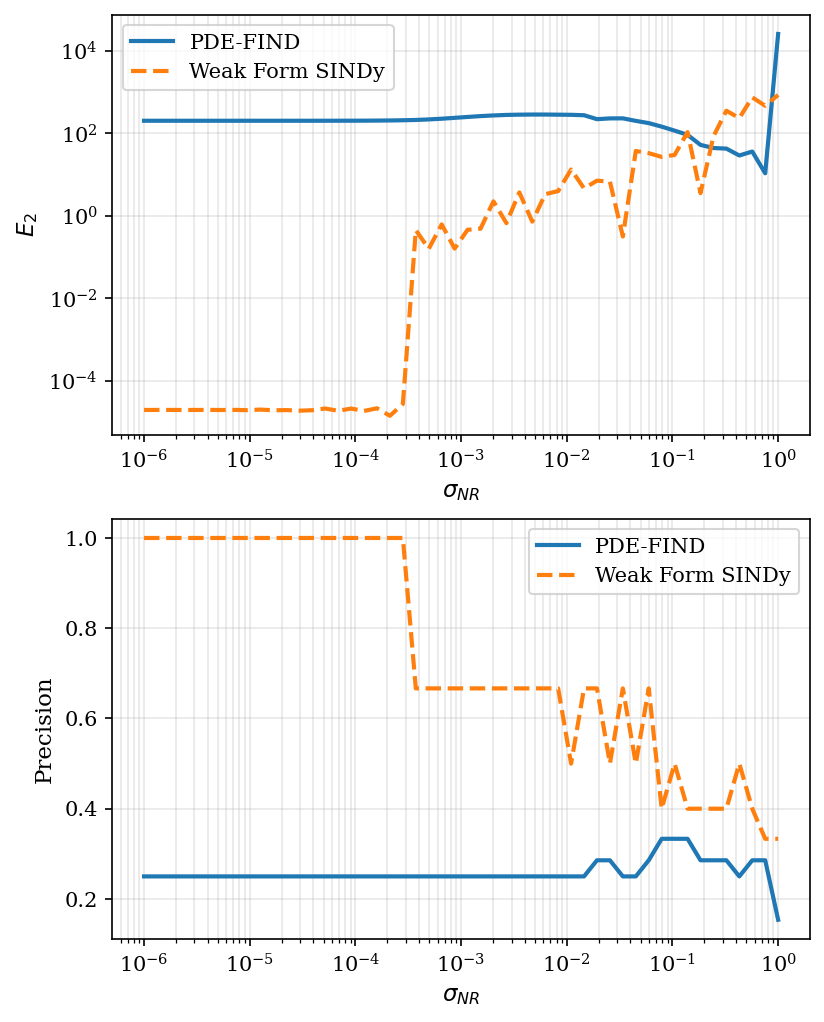

In [22]:
# Define the true coefficient matrix for SINDy
xi_sindy = np.zeros((1, 20))
xi_sindy[0, 6] = -1.0
xi_sindy[0, 8] = -1.0

# Define the true coefficient matrix for WSINDy
xi_wsindy = np.zeros((16, 1))
xi_wsindy[5, 0] = -0.5
xi_wsindy[10, 0] = -1.0

# Benchmark the methods
benchmark_wsindy_pde(
    kdv_noisy_us, noise_ratios,
    kdv_x, kdv_t,
    xi_sindy, xi_wsindy,
    wsindy_kwargs={
        'poly_order': poly_order,
        'include_bias': include_bias,
        'lam': lam,
        'max_dx': max_dx
    },
    sindy_lib_kwargs={
        'function_library': ps.PolynomialLibrary(poly_order, include_bias=False),
        'derivative_order': max_dx,
        'include_bias': include_bias,
        'spatial_grid': kdv_x,
        'diff_kwargs': {'periodic': True}
    },
    sindy_opti_kwargs={'threshold': 1e7, 'normalize_columns': True}
)

In general, when learning PDEs with SINDy, one should always strive to use the weak form, even with clean data. This is due to the high collinearity between different partial derivatives. In PySINDy, this can be applied using `ps.WeakPDELibrary`.